In [2]:
import pandas as pd

# 1. Read the CSV file
df = pd.read_csv('C2022_A/c2022_a_rv.csv')

# 2. View the first 5 rows (the head)
print(df.head())

# 3. View just the column header names
print(df.columns.tolist())

   UNITID  CIPCODE  MAJORNUM  AWLEVEL XCTOTALT  CTOTALT XCTOTALM  CTOTALM  \
0  100654   1.0999         1        5        R        9        R        3   
1  100654   1.1001         1        5        R        7        R        3   
2  100654   1.1001         1        7        R        7        R        1   
3  100654   1.1001         1       17        R        3        R        1   
4  100654   1.9999         1        5        R        1        R        1   

  XCTOTALW  CTOTALW  ... XCUNKNM  CUNKNM XCUNKNW  CUNKNW XCNRALT  CNRALT  \
0        R        6  ...       Z       0       Z       0       Z       0   
1        R        4  ...       Z       0       Z       0       Z       0   
2        R        6  ...       Z       0       R       2       R       2   
3        R        2  ...       Z       0       Z       0       Z       0   
4        Z        0  ...       Z       0       Z       0       Z       0   

  XCNRALM  CNRALM XCNRALW  CNRALW    
0       Z       0       Z         0  
1   

In [4]:

import pandas as pd

df = pd.read_csv("C2022_A/c2022_a_rv.csv", dtype={"CIPCODE": str})

print(df.head())
print(df.columns)

   UNITID  CIPCODE  MAJORNUM  AWLEVEL XCTOTALT  CTOTALT XCTOTALM  CTOTALM  \
0  100654  01.0999         1        5        R        9        R        3   
1  100654  01.1001         1        5        R        7        R        3   
2  100654  01.1001         1        7        R        7        R        1   
3  100654  01.1001         1       17        R        3        R        1   
4  100654  01.9999         1        5        R        1        R        1   

  XCTOTALW  CTOTALW  ... XCUNKNM  CUNKNM XCUNKNW  CUNKNW XCNRALT  CNRALT  \
0        R        6  ...       Z       0       Z       0       Z       0   
1        R        4  ...       Z       0       Z       0       Z       0   
2        R        6  ...       Z       0       R       2       R       2   
3        R        2  ...       Z       0       Z       0       Z       0   
4        Z        0  ...       Z       0       Z       0       Z       0   

  XCNRALM  CNRALM XCNRALW  CNRALW    
0       Z       0       Z         0  
1   

In [6]:
degree_map = {
    3: "Associate",
    5: "Bachelor",
    7: "Master",
    17: "PhD / Doctor Research"
}

df2 = df[df["AWLEVEL"].isin(degree_map.keys())].copy()
df2["degree_level"] = df2["AWLEVEL"].map(degree_map)

summary = (
    df2.groupby(["degree_level", "CIPCODE"], as_index=False)["CTOTALT"]
    .sum()
    .sort_values(["degree_level", "CTOTALT"], ascending=[True, False])
)

print(summary.head(5))

     degree_level  CIPCODE  CTOTALT
1030    Associate       99  1016944
423     Associate  24.0101   249611
424     Associate  24.0102    96531
927     Associate  51.3801    82018
942     Associate  52.0201    58693


In [8]:
import pandas as pd

df = pd.read_csv("C2022_A/c2022_a_rv.csv", dtype={"CIPCODE": str})

degree_map = {
    3: "Associate",
    5: "Bachelor",
    7: "Master",
    17: "PhD / Doctor Research"
}

df["AWLEVEL"] = pd.to_numeric(df["AWLEVEL"], errors="coerce")
df["CTOTALT"] = pd.to_numeric(df["CTOTALT"], errors="coerce").fillna(0)

# Keep only AS, BS, MS, PhD
df2 = df[df["AWLEVEL"].isin(degree_map.keys())].copy()

# Remove total/summary major code
df2 = df2[df2["CIPCODE"] != "99"]

df2["year"] = 2022
df2["degree_level"] = df2["AWLEVEL"].map(degree_map)

summary = (
    df2.groupby(["year", "degree_level", "CIPCODE"], as_index=False)["CTOTALT"]
    .sum()
    .rename(columns={
        "CIPCODE": "major_code",
        "CTOTALT": "degree_count"
    })
)

print(summary.head(5).to_string(index=False))

 year degree_level major_code  degree_count
 2022    Associate    01.0000           812
 2022    Associate    01.0101           577
 2022    Associate    01.0102           725
 2022    Associate    01.0103            23
 2022    Associate    01.0104            97


In [10]:
import pandas as pd

# Your IPEDS completions file
df = pd.read_csv("C2022_A/c2022_a_rv.csv", dtype={"CIPCODE": str})

# Downloaded CIP name file from NCES
cip = pd.read_csv("CIPCode2020.csv", dtype=str)

print(cip.columns)

Index(['CIPFamily', 'CIPCode', 'Action', 'TextChange', 'CIPTitle',
       'CIPDefinition', 'CrossReferences', 'Examples'],
      dtype='object')


In [12]:
import pandas as pd
import re

df = pd.read_csv("C2022_A/c2022_a_rv.csv", dtype={"CIPCODE": str})
cip = pd.read_csv("CIPCode2020.csv", dtype=str)

def clean_cip(code):
    if pd.isna(code):
        return None
    
    code = str(code).strip()
    
    # keep only numbers
    digits = re.sub(r"[^0-9]", "", code)
    
    # convert 240101 -> 24.0101
    if len(digits) == 6:
        return digits[:2] + "." + digits[2:]
    
    return None

# Clean IPEDS major code
df["major_code"] = df["CIPCODE"].apply(clean_cip)

# Clean CIP lookup major code
cip["major_code"] = cip["CIPCode"].apply(clean_cip)

cip_lookup = cip[["major_code", "CIPTitle"]].copy()
cip_lookup = cip_lookup.rename(columns={"CIPTitle": "major_name"})

# Remove bad rows
cip_lookup = cip_lookup.dropna(subset=["major_code"])
cip_lookup = cip_lookup.drop_duplicates(subset=["major_code"])

# write and download see the file that are clean:

In [15]:
#write the file name for summary of clean and print next file 
# Save the cleaned degree-level/major summary as a CSV file
summary.to_csv("IPEDS_2022_degree_level_major_name.csv", index=False)

In [17]:
#this is for print
degree_map = {
    3: "Associate",
    5: "Bachelor",
    7: "Master",
    17: "PhD / Doctor Research"
}

df["AWLEVEL"] = pd.to_numeric(df["AWLEVEL"], errors="coerce")
df["CTOTALT"] = pd.to_numeric(df["CTOTALT"], errors="coerce").fillna(0)

# Keep only AS, BS, MS, PhD
df2 = df[df["AWLEVEL"].isin(degree_map.keys())].copy()

# Keep only real major codes like 24.0101, 11.0101, 14.1001
df2 = df2[df2["CIPCODE"].str.match(r"^\d{2}\.\d{4}$", na=False)]

df2["year"] = 2022
df2["degree_level"] = df2["AWLEVEL"].map(degree_map)

summary = (
    df2.groupby(["year", "degree_level", "CIPCODE"], as_index=False)["CTOTALT"]
    .sum()
    .rename(columns={
        "CIPCODE": "major_code",
        "CTOTALT": "degree_count"
    })
)

# Add major name
summary = summary.merge(cip_lookup, on="major_code", how="left")

# Final clean table
summary = summary[[
    "year",
    "degree_level",
    "major_code",
    "major_name",
    "degree_count"
]]

summary = summary.sort_values(
    ["degree_level", "degree_count"],
    ascending=[True, False]
)

print(summary.head(5).to_string(index=False))

 year degree_level major_code                                       major_name  degree_count
 2022    Associate    24.0101       Liberal Arts and Sciences/Liberal Studies.        249611
 2022    Associate    24.0102                                 General Studies.         96531
 2022    Associate    51.3801             Registered Nursing/Registered Nurse.         82018
 2022    Associate    52.0201 Business Administration and Management, General.         58693
 2022    Associate    30.0101                Biological and Physical Sciences.         25622


In [49]:
# -----------------------------
# Add field_of_study column only
# -----------------------------

def map_field_of_study(major):
    major = str(major).lower()

    if any(word in major for word in ["agriculture", "animal", "plant", "veterinary", "natural resources", "conservation"]):
        return "Agriculture and natural resources"

    elif any(word in major for word in ["architecture"]):
        return "Architecture and related services"

    elif any(word in major for word in ["ethnic", "cultural", "gender", "area studies"]):
        return "Area, ethnic, cultural, gender, and group studies"

    elif any(word in major for word in ["biology", "biological", "biomedical", "biochemistry", "genetics", "microbiology"]):
        return "Biological and biomedical sciences"

    elif any(word in major for word in ["business", "accounting", "marketing", "management", "finance", "commerce", "entrepreneurship"]):
        return "Business"

    elif any(word in major for word in ["communication", "journalism", "media"]):
        return "Communication, journalism, and related programs"

    elif any(word in major for word in ["computer", "information science", "data", "cyber", "software", "programming"]):
        return "Computer and information sciences and support services"

    elif any(word in major for word in ["education", "teaching", "teacher"]):
        return "Education"

    elif any(word in major for word in ["engineering technology", "engineering technician", "mechanic", "repair", "construction"]):
        return "Engineering technologies"

    elif any(word in major for word in ["engineering", "electrical", "mechanical", "civil", "chemical", "aerospace", "industrial"]):
        return "Engineering"

    elif any(word in major for word in ["english", "literature", "letters", "writing"]):
        return "English language and literature/letters"

    elif any(word in major for word in ["health", "nursing", "medical", "dental", "pharmacy", "therapy", "clinical"]):
        return "Health professions and related programs"

    elif any(word in major for word in ["liberal arts", "general studies", "humanities"]):
        return "Liberal arts and sciences, general studies, and humanities"

    elif any(word in major for word in ["mathematics", "statistics", "math"]):
        return "Mathematics and statistics"

    elif any(word in major for word in ["psychology"]):
        return "Psychology"

    elif any(word in major for word in ["social science", "sociology", "political science", "economics", "history"]):
        return "Social sciences and history"

    elif any(word in major for word in ["visual", "performing arts", "art", "music", "dance", "design", "drama", "film"]):
        return "Visual and performing arts"

    else:
        return "Other"


# Add new column only
summary["field_of_study"] = summary["major_name"].apply(map_field_of_study)

# Keep old table + new column
summary = summary[[
    "year",
    "degree_level",
    "major_code",
    "major_name",
    "field_of_study",
    "degree_count"
]]

# Sort
summary = summary.sort_values(
    ["degree_level", "degree_count"],
    ascending=[True, False]
)

# Print first 5 rows only
print(summary.head(5).to_string(index=False))

#Write new file:
summary.to_csv("IPEDS_2022_with_field_of_study.csv", index=False)

#print(summary)

 year degree_level major_code                                       major_name                                             field_of_study  degree_count
 2022    Associate    24.0101       Liberal Arts and Sciences/Liberal Studies. Liberal arts and sciences, general studies, and humanities        249611
 2022    Associate    24.0102                                 General Studies. Liberal arts and sciences, general studies, and humanities         96531
 2022    Associate    51.3801             Registered Nursing/Registered Nurse.                    Health professions and related programs         82018
 2022    Associate    52.0201 Business Administration and Management, General.                                                   Business         58693
 2022    Associate    30.0101                Biological and Physical Sciences.                         Biological and biomedical sciences         25622


# Print summary

In [51]:
import pandas as pd
'''
# =========================
# 1. PRINT FIRST 10 ROWS
# =========================
print("\n--- FIRST 10 ROWS ---")
print(summary.head(10).to_string(index=False))


# =========================
# 2. PRINT LAST 10 ROWS
# =========================
print("\n--- LAST 10 ROWS ---")
print(summary.tail(10).to_string(index=False))


# =========================
# 3. CHECK TABLE SIZE
# =========================
print("\n--- TABLE SIZE ---")
print(summary.shape)   # shows (rows, columns)


# =========================
# 4. CHECK COLUMN NAMES
# =========================
print("\n--- COLUMN NAMES ---")
print(summary.columns)


# =========================
# 5. CHECK DATA TYPES
# =========================
print("\n--- DATA TYPES ---")
print(summary.dtypes)


# =========================
# 6. CHECK MISSING VALUES
# =========================
print("\n--- MISSING VALUES ---")
print(summary.isna().sum())


# =========================
# 7. COUNT DEGREE LEVELS
# =========================
print("\n--- DEGREE LEVEL COUNTS ---")
print(summary["degree_level"].value_counts())


# =========================
# 8. COUNT FIELD OF STUDY
# =========================
# Only works if you already added field_of_study column
print("\n--- FIELD OF STUDY COUNTS ---")
print(summary["field_of_study"].value_counts())


# =========================
# 9. TOP 30 BIGGEST DEGREE COUNTS
# =========================
print("\n--- TOP 30 BIGGEST DEGREE COUNTS ---")
print(
    summary.sort_values("degree_count", ascending=False)
    .head(30)
    .to_string(index=False)
)


# =========================
# 10. PRINT ONLY IMPORTANT COLUMNS
# =========================
print("\n--- IMPORTANT COLUMNS ONLY ---")
print(
    summary[[
        "degree_level",
        "major_code",
        "major_name",
        "field_of_study",
        "degree_count"
    ]]
    .head(30)
    .to_string(index=False)
)


# =========================
# 11. TOP 30 BY DEGREE COUNT WITH IMPORTANT COLUMNS
# =========================
print("\n--- TOP 30 IMPORTANT COLUMNS BY DEGREE COUNT ---")
print(
    summary.sort_values("degree_count", ascending=False)
    [[
        "degree_level",
        "major_code",
        "major_name",
        "field_of_study",
        "degree_count"
    ]]
    .head(30)
    .to_string(index=False)
)


# =========================
# 12. TOTAL DEGREES BY DEGREE LEVEL
# =========================
print("\n--- TOTAL DEGREES BY DEGREE LEVEL ---")
print(
    summary.groupby("degree_level")["degree_count"]
    .sum()
    .sort_values(ascending=False)
    .to_string()
)


# =========================
# 13. TOTAL DEGREES BY FIELD OF STUDY
# =========================
print("\n--- TOTAL DEGREES BY FIELD OF STUDY ---")
print(
    summary.groupby("field_of_study")["degree_count"]
    .sum()
    .sort_values(ascending=False)
    .to_string()
)


# =========================
# 14. FIELD OF STUDY + DEGREE LEVEL SUMMARY
# =========================
print("\n--- FIELD OF STUDY BY DEGREE LEVEL ---")
field_degree_summary = (
    summary.groupby(["field_of_study", "degree_level"])["degree_count"]
    .sum()
    .reset_index()
    .sort_values(["field_of_study", "degree_count"], ascending=[True, False])
)

print(field_degree_summary.to_string(index=False))


# =========================
# 15. FILTER EXAMPLE: ONLY BACHELOR
# =========================
print("\n--- ONLY BACHELOR TOP 20 ---")
bachelor_only = summary[summary["degree_level"] == "Bachelor"]

print(
    bachelor_only.sort_values("degree_count", ascending=False)
    .head(20)
    .to_string(index=False)
)


# =========================
# 16. FILTER EXAMPLE: ONLY COMPUTER FIELD
# =========================
print("\n--- COMPUTER FIELD ONLY ---")
computer_only = summary[
    summary["field_of_study"] == "Computer and information sciences and support services"
]

print(
    computer_only.sort_values("degree_count", ascending=False)
    .head(20)
    .to_string(index=False)
)


# =========================
# 17. FILTER EXAMPLE: ONLY HEALTH FIELD
# =========================
print("\n--- HEALTH FIELD ONLY ---")
health_only = summary[
    summary["field_of_study"] == "Health professions and related programs"
]

print(
    health_only.sort_values("degree_count", ascending=False)
    .head(20)
    .to_string(index=False)
)


# =========================
# 18. FILTER EXAMPLE: ONLY ENGINEERING FIELD
# =========================
print("\n--- ENGINEERING FIELD ONLY ---")
engineering_only = summary[
    summary["field_of_study"] == "Engineering"
]

print(
    engineering_only.sort_values("degree_count", ascending=False)
    .head(20)
    .to_string(index=False)
)
'''

'\n# =========================\n# 1. PRINT FIRST 10 ROWS\n# =========================\nprint("\n--- FIRST 10 ROWS ---")\nprint(summary.head(10).to_string(index=False))\n\n\n# =========================\n# 2. PRINT LAST 10 ROWS\n# =========================\nprint("\n--- LAST 10 ROWS ---")\nprint(summary.tail(10).to_string(index=False))\n\n\n# =========================\n# 3. CHECK TABLE SIZE\n# =========================\nprint("\n--- TABLE SIZE ---")\nprint(summary.shape)   # shows (rows, columns)\n\n\n# =========================\n# 4. CHECK COLUMN NAMES\n# =========================\nprint("\n--- COLUMN NAMES ---")\nprint(summary.columns)\n\n\n# =========================\n# 5. CHECK DATA TYPES\n# =========================\nprint("\n--- DATA TYPES ---")\nprint(summary.dtypes)\n\n\n# =========================\n# 6. CHECK MISSING VALUES\n# =========================\nprint("\n--- MISSING VALUES ---")\nprint(summary.isna().sum())\n\n\n# =========================\n# 7. COUNT DEGREE LEVELS\n# ==

Index(['year', 'degree_level', 'major_code', 'major_name', 'field_of_study',
       'degree_count'],
      dtype='object')
   year degree_level  major_code  \
0  2022    Associate     24.0101   
1  2022    Associate     24.0102   
2  2022    Associate     51.3801   
3  2022    Associate     52.0201   
4  2022    Associate     30.0101   

                                         major_name  \
0        Liberal Arts and Sciences/Liberal Studies.   
1                                  General Studies.   
2              Registered Nursing/Registered Nurse.   
3  Business Administration and Management, General.   
4                 Biological and Physical Sciences.   

                                      field_of_study  degree_count  
0  Liberal arts and sciences, general studies, an...        249611  
1  Liberal arts and sciences, general studies, an...         96531  
2            Health professions and related programs         82018  
3                                           Business 

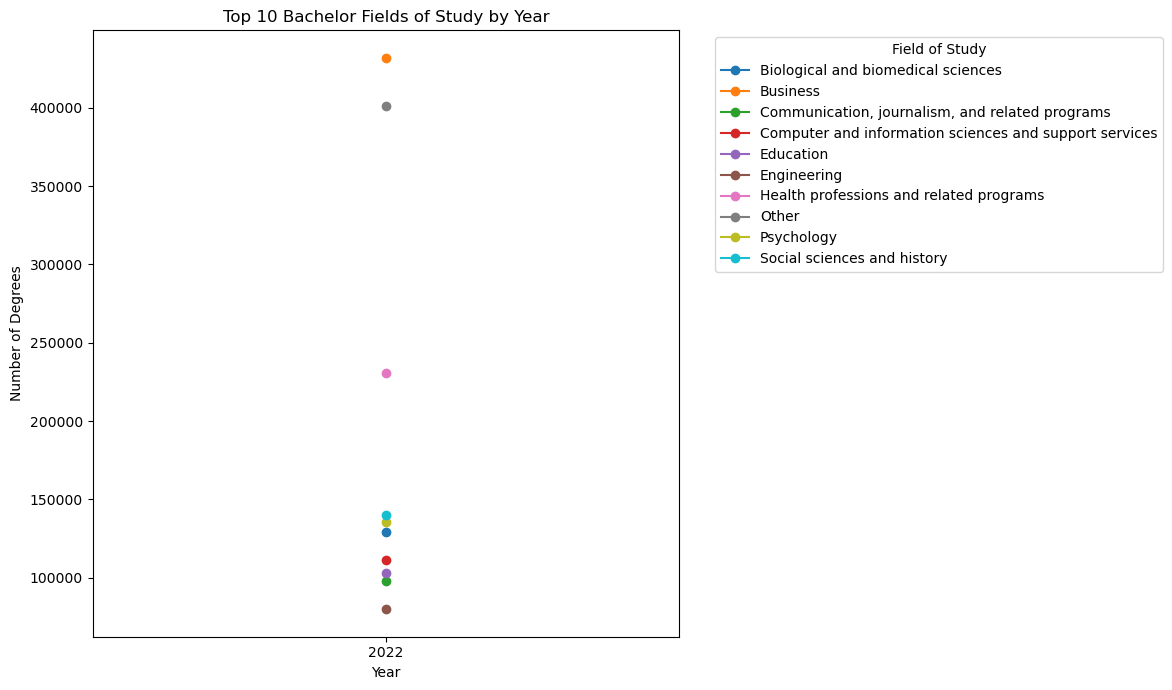

In [55]:
# Create a line chart showing how degree counts change by year for each field of study

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. READ NEW FILE
# =========================

final_dataset = pd.read_csv("IPEDS_2022_with_field_of_study.csv")

# Check columns
print(final_dataset.columns)
print(final_dataset.head())


# =========================
# 2. CLEAN COLUMNS
# =========================

final_dataset["year"] = pd.to_numeric(final_dataset["year"], errors="coerce")
final_dataset["degree_count"] = pd.to_numeric(final_dataset["degree_count"], errors="coerce")


# =========================
# 3. CHOOSE DEGREE LEVEL
# =========================

degree = "Bachelor"   # change to Associate, Master, or PhD / Doctor
top_n = 10            # top 10 fields of study


# =========================
# 4. FILTER BY DEGREE LEVEL
# =========================

df_plot = final_dataset[final_dataset["degree_level"] == degree].copy()


# =========================
# 5. GET TOP FIELD OF STUDY
# =========================

top_fields = (
    df_plot.groupby("field_of_study")["degree_count"]
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

df_plot = df_plot[df_plot["field_of_study"].isin(top_fields)]


# =========================
# 6. CREATE PIVOT TABLE
# =========================

pivot = df_plot.pivot_table(
    index="year",
    columns="field_of_study",
    values="degree_count",
    aggfunc="sum",
    fill_value=0
)

print(pivot)


# =========================
# 7. PLOT LINE CHART
# =========================

plt.figure(figsize=(12, 7))

for field in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[field],
        marker="o",
        label=field
    )

plt.title(f"Top {top_n} {degree} Fields of Study by Year")
plt.xlabel("Year")
plt.ylabel("Number of Degrees")

# If your file only has 2022, this will show one point
plt.xticks(pivot.index)

# Optional fixed year range
# plt.xlim(2022, 2026)

plt.legend(title="Field of Study", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

field_of_study  Agriculture and natural resources  Architecture and related services  Area, ethnic, cultural, gender, and group studies  Biological and biomedical sciences  Business  Communication, journalism, and related programs  Computer and information sciences and support services  Education  Engineering  Engineering technologies  English language and literature/letters  Health professions and related programs  Liberal arts and sciences, general studies, and humanities  Mathematics and statistics   Other  Psychology  Social sciences and history  Visual and performing arts
year                                                                                                                                                                                                                                                                                                                                                                                                                            

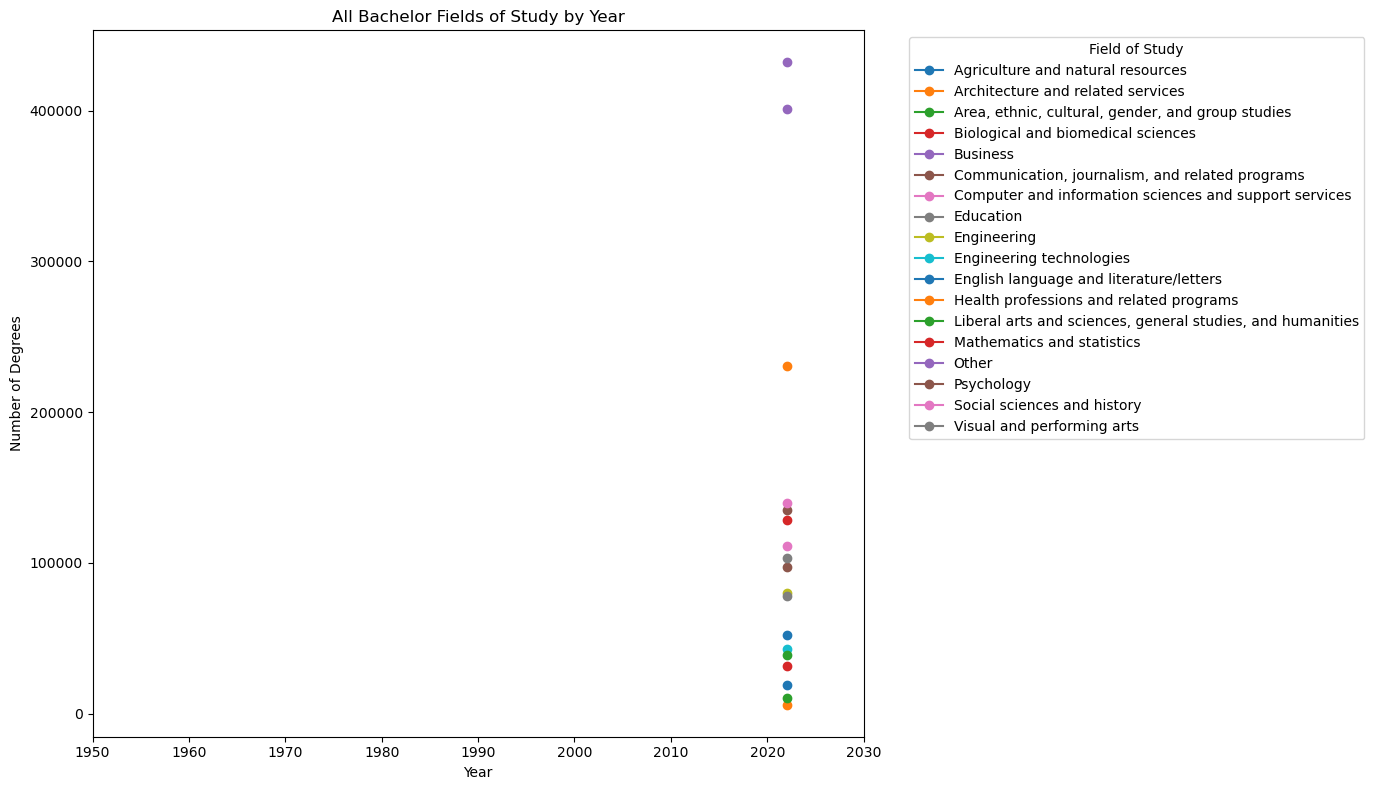

In [57]:
# Create a line chart showing how degree counts change by year for each field of study
# No top 10 limit

import pandas as pd
import matplotlib.pyplot as plt

# Read new file
final_dataset = pd.read_csv("IPEDS_2022_with_field_of_study.csv")

# Clean numeric columns
final_dataset["year"] = pd.to_numeric(final_dataset["year"], errors="coerce")
final_dataset["degree_count"] = pd.to_numeric(final_dataset["degree_count"], errors="coerce")

# Choose degree level
degree = "Bachelor"   # change to Associate, Master, or PhD / Doctor

# Filter by degree level
df_plot = final_dataset[final_dataset["degree_level"] == degree].copy()

# Create pivot table using ALL fields of study
pivot = df_plot.pivot_table(
    index="year",
    columns="field_of_study",
    values="degree_count",
    aggfunc="sum",
    fill_value=0
)

# Print the stacked table first
print(pivot.to_string())

# Plot line chart
plt.figure(figsize=(14, 8))

for field in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[field],
        marker="o",
        label=field
    )

plt.title(f"All {degree} Fields of Study by Year")
plt.xlabel("Year")
plt.ylabel("Number of Degrees")

# Fix year axis
plt.xlim(1950, 2030)

plt.legend(title="Field of Study", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

degree_level                                                Associate  Bachelor  Master  PhD / Doctor   Total
field_of_study                                                                                               
Architecture and related services                                 124      6048    1344           101    7617
Area, ethnic, cultural, gender, and group studies                2865     10598    1807           437   15707
Agriculture and natural resources                                7254     19015    4648          1147   32064
Mathematics and statistics                                       4248     31350   12817          2499   50914
English language and literature/letters                          5161     51921    9999          1874   68955
Engineering technologies                                        24851     43262    7848          1985   77946
Visual and performing arts                                      26629     78413   12626          2024  119692
Communicat

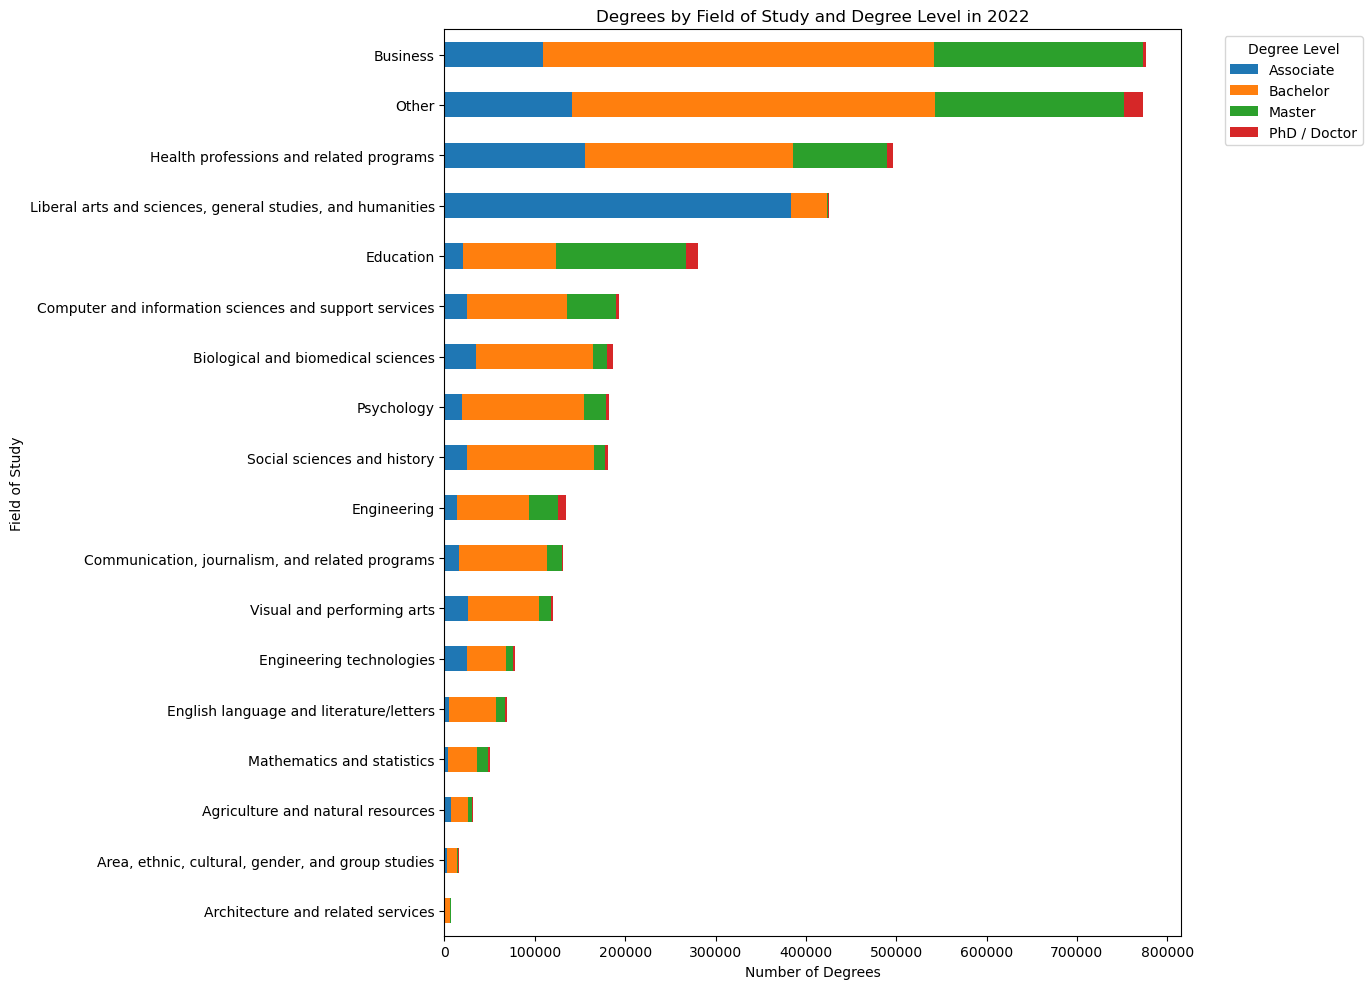

In [62]:
# Stacked bar chart: Field of Study by Degree Level

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. READ FILE
# =========================
final_dataset = pd.read_csv("IPEDS_2022_with_field_of_study.csv")

# =========================
# 2. CLEAN NUMERIC COLUMNS
# =========================
final_dataset["year"] = pd.to_numeric(final_dataset["year"], errors="coerce")
final_dataset["degree_count"] = pd.to_numeric(final_dataset["degree_count"], errors="coerce")

# =========================
# 3. CHOOSE YEAR
# =========================
year_choice = 2022

df_plot = final_dataset[final_dataset["year"] == year_choice].copy()

# =========================
# 4. CREATE PIVOT TABLE
# =========================
pivot = df_plot.pivot_table(
    index="field_of_study",
    columns="degree_level",
    values="degree_count",
    aggfunc="sum",
    fill_value=0
)

# =========================
# 5. PUT DEGREE COLUMNS IN ORDER
# =========================
degree_order = [
    "Associate",
    "Bachelor",
    "Master",
    "PhD / Doctor"
]

pivot = pivot[[col for col in degree_order if col in pivot.columns]]

# =========================
# 6. SORT BY TOTAL
# =========================
pivot["Total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("Total", ascending=True)

# Remove Total before chart
pivot_chart = pivot.drop(columns="Total")

# =========================
# 7. PRINT STACKED TABLE
# =========================
print(pivot.to_string())

# =========================
# 8. CREATE STACKED BAR CHART
# =========================
pivot_chart.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 10)
)

plt.title(f"Degrees by Field of Study and Degree Level in {year_choice}")
plt.xlabel("Number of Degrees")
plt.ylabel("Field of Study")
plt.legend(title="Degree Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()